# Import All Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
!pip install openpyxl


# Import Heatmap Data 

In [19]:
data = pd.read_excel('C:/Users/JOHN/Desktop/heatmap_data.xlsx')


In [21]:
data

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


# Select Relevant Columns

In [28]:
selected_columns = ['Task Completion Rates', 'Decision-Making Skills Rating', 'Sales Revenue Generated']
data_selected = data[selected_columns]


In [30]:
selected_columns

['Task Completion Rates',
 'Decision-Making Skills Rating',
 'Sales Revenue Generated']

# Create and Round Correlation Matrix

In [33]:
corr_matrix = data_selected.corr().round(3)

In [35]:
print(corr_matrix)

                               Task Completion Rates  \
Task Completion Rates                          1.000   
Decision-Making Skills Rating                  0.708   
Sales Revenue Generated                        0.225   

                               Decision-Making Skills Rating  \
Task Completion Rates                                  0.708   
Decision-Making Skills Rating                          1.000   
Sales Revenue Generated                               -0.059   

                               Sales Revenue Generated  
Task Completion Rates                            0.225  
Decision-Making Skills Rating                   -0.059  
Sales Revenue Generated                          1.000  


# Heatmap Plot

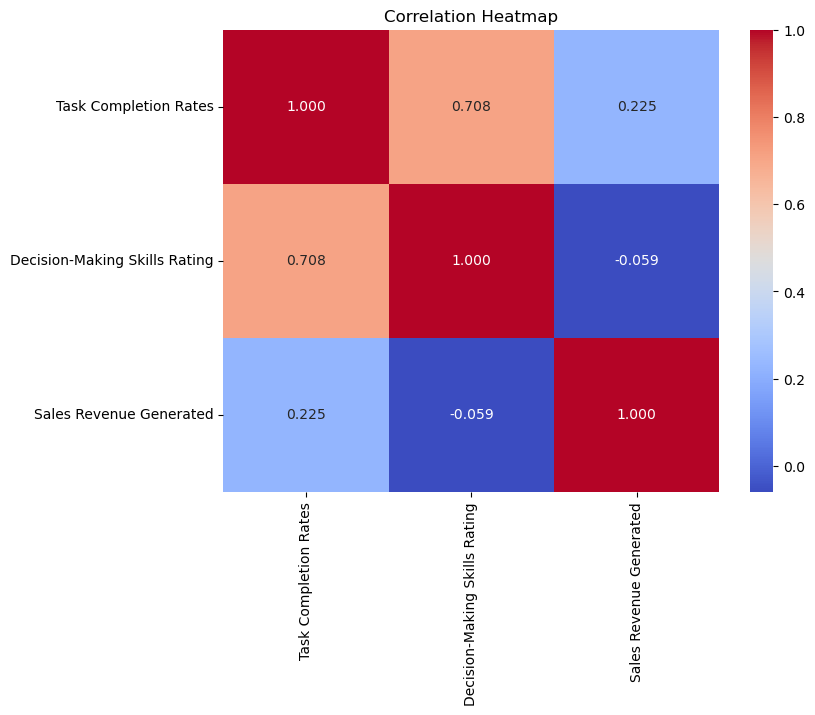

In [38]:
# Using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap')
plt.show()


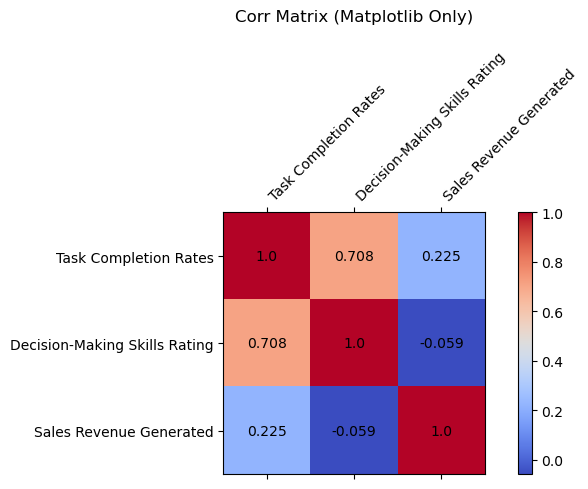

In [50]:
# Plot using matplotlib

fig, ax = plt.subplots(figsize=(8, 5))
cax = ax.matshow(corr_matrix, cmap='coolwarm')

fig.colorbar(cax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)

# Correlative Value
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, str(value), va='center', ha='center', color='black')

plt.title('Corr Matrix (Matplotlib Only)', pad=20)
plt.tight_layout()
plt.show()